# Denoise benchmark (10 frames) + interactive viewer

Keeps the 3-panel viewer (RAW / Detected noise / Denoised) and benchmarks 10 frames from the HDF5 dataset.


In [1]:
# =========================
# Cell 0 — Imports & USER CONFIG
# =========================
import sys, time
import numpy as np
import h5py
from pathlib import Path
import pandas as pd

from scipy.ndimage import median_filter, binary_dilation, gaussian_filter

# Viewer
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display

# Denoisers
from skimage.restoration import denoise_nl_means, estimate_sigma
import bm3d

# ---- Interactive matplotlib (like your screenshot). If it errors, comment it out. ----
%matplotlib widget

# =========================
# USER CONFIG (edit here)
# =========================
ROOT_IN = Path("/Users/lvmeizhong/Desktop/denoise/exports_processed_clean_win0")
WINS = [0]  # which win folders exist under ROOT_IN

# H5 input file name pattern under ROOT_IN/winXX/
H5_NAME = "processed_win{win:02d}_left512.h5"

# Background / sigma-clip
SMOOTH_SIGMA = 40
CLIP_K = 3.0
N_ITER = 4
DILATE_R = 4

# Noise model params for GAT
ALPHA = 1.0
SIGMA_READ = 0.0

# NLM params
NLM_H_SCALE = 1.0
NLM_PATCH_SIZE = 7
NLM_PATCH_DISTANCE = 11

# Optional despike (default OFF)
APPLY_DESPIKE = False
DESPIKE_MED = 5
DESPIKE_K = 8.0
DESPIKE_DILATE = 1

# BM3D speed/quality tradeoff
BM3D_STAGE_FAST = bm3d.BM3DStages.HARD_THRESHOLDING  # faster (1st stage only)
# BM3D_STAGE_FAST = bm3d.BM3DStages.ALL_STAGES       # slower, better

# Benchmark sampling
N_BENCH = 10
BENCH_SEED = 0
METHODS_BENCH = ["gat_bm3d", "gat_nlm", "bm3d_only"]  # which methods to time

print("ROOT_IN:", ROOT_IN)


/Users/lvmeizhong/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/lvmeizhong/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


ROOT_IN: /Users/lvmeizhong/Desktop/denoise/exports_processed_clean_win0


In [2]:
# =========================
# Cell 1 — HDF5 helpers
# =========================
_h5_cache = {}

def _get_h5(win: int):
    win = int(win)
    if win in _h5_cache and _h5_cache[win].id.valid:
        return _h5_cache[win]
    p = ROOT_IN / f"win{win:02d}" / H5_NAME.format(win=win)
    if not p.exists():
        raise FileNotFoundError(f"Cannot find: {p}")
    _h5_cache[win] = h5py.File(p, "r")
    return _h5_cache[win]

def get_shapes(win: int):
    f = _get_h5(win)
    H, W, detH, detW = f["img"].shape  # expected img[H,W,detH,detW]
    return int(H), int(W), int(detH), int(detW)

def read_detector(win: int, iy: int, ix: int):
    f = _get_h5(win)
    return f["img"][int(iy), int(ix)].astype(np.float32)

for w in WINS:
    H, W, detH, detW = get_shapes(w)
    print(f"[win={w}] HxW={H}x{W}, det={detH}x{detW}")


[win=0] HxW=141x121, det=512x512


In [3]:
# =========================
# Cell 2 — Background & masks
# =========================
def robust_sigma_mad(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def despike_mask_2d(img, med_size=5, k=8.0, dilate=1):
    img = np.asarray(img, dtype=np.float32)
    bg = median_filter(img, size=int(med_size), mode="mirror")
    resid = img - bg
    mad = np.median(np.abs(resid - np.median(resid)))
    sigma = 1.4826 * mad + 1e-12
    mask = resid > (float(k) * sigma)
    if int(dilate) > 0:
        mask = binary_dilation(mask, iterations=int(dilate))
    return mask, bg

def estimate_bg_sigma_clip(img, smooth_sigma=25, k=4.0, n_iter=4):
    I = np.asarray(img, dtype=np.float32)
    nan_mask = ~np.isfinite(I)

    med0 = np.nanmedian(I)
    I0 = I.copy()
    I0[nan_mask] = med0

    bg = gaussian_filter(I0, smooth_sigma, mode="reflect")

    sig_mask = np.zeros_like(I, dtype=bool)
    for _ in range(int(n_iter)):
        resid = I - bg
        sigma = robust_sigma_mad(resid)

        sig_mask = np.isfinite(resid) & (resid > (float(k) * sigma))

        work = I.copy()
        work[nan_mask] = bg[nan_mask]
        work[sig_mask] = bg[sig_mask]
        bg = gaussian_filter(work, smooth_sigma, mode="reflect")

    resid = I - bg
    return bg.astype(np.float32), sig_mask, resid.astype(np.float32)


In [4]:
# =========================
# Cell 3 — GAT + denoisers (fast BM3D)
# =========================
def gat_forward(y, alpha=1.0, sigma_read=0.0):
    y = np.asarray(y, np.float32)
    return (2.0 / alpha) * np.sqrt(alpha * y + 3.0/8.0 * alpha**2 + sigma_read**2)

def gat_inverse_approx(z, alpha=1.0, sigma_read=0.0):
    z = np.asarray(z, np.float32)
    y = (((alpha * z) / 2.0) ** 2 - 3.0/8.0 * alpha**2 - sigma_read**2) / alpha
    return y

def robust_unit_interval(x, p_lo=0.5, p_hi=99.5):
    lo = float(np.nanpercentile(x, p_lo))
    hi = float(np.nanpercentile(x, p_hi))
    x01 = np.clip((x - lo) / (hi - lo + 1e-12), 0.0, 1.0)
    return x01.astype(np.float32), lo, hi

def denoise_gat_nlm_on_resid(resid, bg, alpha=1.0, sigma_read=0.0,
                            h_scale=1.0, patch_size=7, patch_distance=11):
    resid0 = np.asarray(resid, np.float32)
    offset = max(0.0, -float(np.nanmin(resid0)))
    resid_pos = resid0 + offset

    z = gat_forward(resid_pos, alpha=alpha, sigma_read=sigma_read)
    sigma_hat = float(np.mean(estimate_sigma(z, channel_axis=None)))

    z_d = denoise_nl_means(
        z,
        h=h_scale * sigma_hat,
        fast_mode=True,
        patch_size=int(patch_size),
        patch_distance=int(patch_distance),
        channel_axis=None,
    ).astype(np.float32)

    resid_pos_d = gat_inverse_approx(z_d, alpha=alpha, sigma_read=sigma_read)
    resid_d = resid_pos_d - offset
    return (bg + resid_d).astype(np.float32)

def denoise_gat_bm3d_on_resid_fast(
    resid, bg,
    alpha=1.0, sigma_read=0.0,
    sigma_psd_fixed=None,
    stage_arg=BM3D_STAGE_FAST
):
    resid0 = np.asarray(resid, np.float32)
    offset = max(0.0, -float(np.nanmin(resid0)))
    resid_pos = resid0 + offset

    z = gat_forward(resid_pos, alpha=alpha, sigma_read=sigma_read)
    z01, lo, hi = robust_unit_interval(z, 0.5, 99.5)

    if sigma_psd_fixed is None:
        sigma_hat = float(np.mean(estimate_sigma(z01, channel_axis=None)))
    else:
        sigma_hat = float(sigma_psd_fixed)

    z01_d = bm3d.bm3d(z01, sigma_psd=sigma_hat, stage_arg=stage_arg).astype(np.float32)
    z_d = z01_d * (hi - lo + 1e-12) + lo

    resid_pos_d = gat_inverse_approx(z_d, alpha=alpha, sigma_read=sigma_read)
    resid_d = resid_pos_d - offset
    return (bg + resid_d).astype(np.float32), sigma_hat

def denoise_bm3d_only(img1):
    x = np.asarray(img1, np.float32)
    x01, lo, hi = robust_unit_interval(x, 0.5, 99.5)
    sigma_hat = float(np.mean(estimate_sigma(x01, channel_axis=None)))
    x01_d = bm3d.bm3d(x01, sigma_psd=sigma_hat, stage_arg=bm3d.BM3DStages.ALL_STAGES).astype(np.float32)
    return (x01_d * (hi - lo + 1e-12) + lo).astype(np.float32)


In [5]:
# =========================
# Cell 4 — Single-frame processing (fast, one method)
# =========================
def process_one_image_fast(img, method="gat_bm3d"):
    t0 = time.perf_counter()

    # 1) despike (optional)
    if APPLY_DESPIKE:
        mask, bg_med = despike_mask_2d(img, DESPIKE_MED, DESPIKE_K, DESPIKE_DILATE)
        img1 = np.asarray(img, np.float32).copy()
        img1[mask] = bg_med[mask]
        masked_frac = float(mask.mean())
    else:
        img1 = np.asarray(img, np.float32)
        masked_frac = 0.0
    t1 = time.perf_counter()

    # 2) bg + resid + sig_mask
    bg, sig_mask, resid = estimate_bg_sigma_clip(
        img1, smooth_sigma=SMOOTH_SIGMA, k=CLIP_K, n_iter=N_ITER
    )
    mask_use = binary_dilation(sig_mask, iterations=int(DILATE_R)) if int(DILATE_R) > 0 else sig_mask
    t2 = time.perf_counter()

    # proxy metrics
    nonsig = ~mask_use
    base_sigma = float(robust_sigma_mad(resid[nonsig])) if np.any(nonsig) else np.nan
    base_neg_frac = float((resid[nonsig] < 0).mean()) if np.any(nonsig) else np.nan

    # 3) denoise (single method)
    td0 = time.perf_counter()
    sigma_used = np.nan

    if method == "gat_nlm":
        den = denoise_gat_nlm_on_resid(
            resid, bg, alpha=ALPHA, sigma_read=SIGMA_READ,
            h_scale=NLM_H_SCALE, patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE
        )

    elif method == "gat_bm3d":
        sigma_fixed = globals().get("SIGMA_PSD_FIXED", None)  # optional (you can define it elsewhere)
        den, sigma_used = denoise_gat_bm3d_on_resid_fast(
            resid, bg, alpha=ALPHA, sigma_read=SIGMA_READ,
            sigma_psd_fixed=sigma_fixed,
            stage_arg=BM3D_STAGE_FAST
        )

    elif method == "bm3d_only":
        den = denoise_bm3d_only(img1)

    else:
        raise ValueError(f"Unknown method: {method}")

    td1 = time.perf_counter()

    out = {
        "pre_ms": 1000.0 * (t1 - t0),
        "bg_ms":  1000.0 * (t2 - t1),
        "denoise_ms": 1000.0 * (td1 - td0),
        "total_ms": 1000.0 * (time.perf_counter() - t0),
        "masked_frac_despike": masked_frac,
        "sig_frac": float(sig_mask.mean()),
        "base_sigma_non_sig": base_sigma,
        "base_neg_frac_non_sig": base_neg_frac,
        "sigma_psd_used": float(sigma_used) if np.isfinite(sigma_used) else np.nan,
    }
    pack = {"bg": bg, "resid": resid, "mask_use": mask_use}
    return out, np.asarray(den, np.float32), pack


In [6]:
# =========================
# Cell 5 — "autotune" for the viewer (runs 3 methods for ONE frame only)
# Keeps the info box and method dropdown.
# =========================
_cache = {}

def _score_non_signal(img_den, bg, mask_use):
    resid_den = (np.asarray(img_den, np.float32) - np.asarray(bg, np.float32))
    nonsig = ~mask_use
    if not np.any(nonsig):
        return np.inf
    return float(robust_sigma_mad(resid_den[nonsig]))

def autotune_one(win: int, iy: int, ix: int):
    key = (int(win), int(iy), int(ix))
    if key in _cache:
        return _cache[key]

    raw = read_detector(win, iy, ix)

    # Background/mask computed once
    if APPLY_DESPIKE:
        mask, bg_med = despike_mask_2d(raw, DESPIKE_MED, DESPIKE_K, DESPIKE_DILATE)
        img1 = raw.copy()
        img1[mask] = bg_med[mask]
    else:
        img1 = raw

    bg, sig_mask, resid = estimate_bg_sigma_clip(img1, smooth_sigma=SMOOTH_SIGMA, k=CLIP_K, n_iter=N_ITER)
    mask_use = binary_dilation(sig_mask, iterations=int(DILATE_R)) if int(DILATE_R) > 0 else sig_mask

    best = {}

    # GAT+NLM
    img_gat_nlm = denoise_gat_nlm_on_resid(
        resid, bg, alpha=ALPHA, sigma_read=SIGMA_READ,
        h_scale=NLM_H_SCALE, patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE
    )
    sc_nlm = _score_non_signal(img_gat_nlm, bg, mask_use)
    best["gat_nlm"] = {"img": img_gat_nlm, "score": sc_nlm, "params": {"h_scale": float(NLM_H_SCALE)}}

    # GAT+BM3D (FAST stage)
    img_gat_bm3d, sigma_used = denoise_gat_bm3d_on_resid_fast(
        resid, bg, alpha=ALPHA, sigma_read=SIGMA_READ,
        sigma_psd_fixed=globals().get("SIGMA_PSD_FIXED", None),
        stage_arg=BM3D_STAGE_FAST
    )
    sc_bm3d = _score_non_signal(img_gat_bm3d, bg, mask_use)
    best["gat_bm3d"] = {"img": img_gat_bm3d, "score": sc_bm3d, "params": {"sigma_psd": float(sigma_used)}}

    # BM3D-only
    img_bm3d = denoise_bm3d_only(img1)
    sc_bm3d_only = _score_non_signal(img_bm3d, bg, mask_use)
    best["bm3d_only"] = {"img": img_bm3d, "score": sc_bm3d_only, "params": {"sigma_psd": np.nan}}

    which = min(["gat_nlm", "gat_bm3d", "bm3d_only"], key=lambda k: best[k]["score"])
    best["auto_best"] = {"img": best[which]["img"], "score": best[which]["score"], "which": which}

    pack = {"raw": raw, "bg": bg, "mask_use": mask_use, "sig_frac": float(sig_mask.mean()), "best": best}
    _cache[key] = pack
    return pack


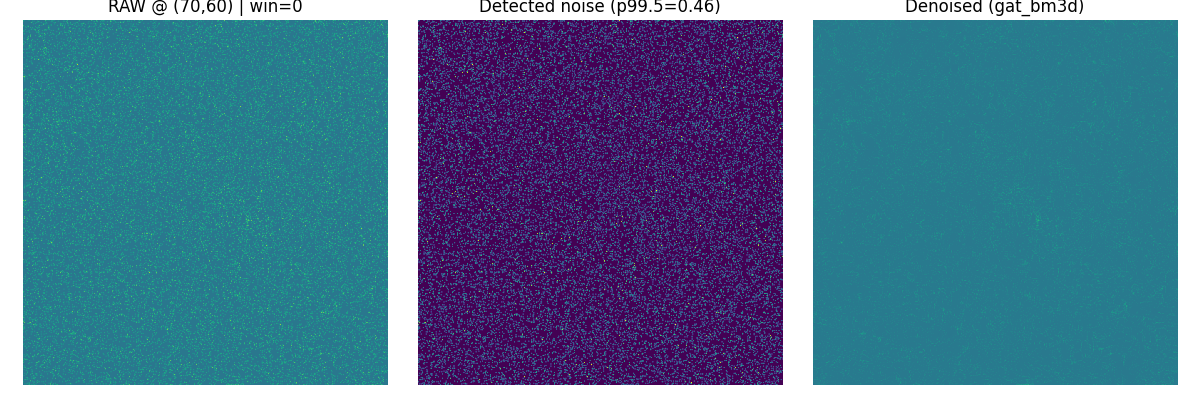

In [7]:
# =========================
# Cell 6 — Interactive viewer (3-panel figure)
# =========================
SL_W = Layout(width="360px")
DD_W = Layout(width="140px")
MD_W = Layout(width="180px")
CK_W = Layout(width="220px")
BTN_W = Layout(width="120px")
ROW_WRAP = Layout(flex_flow="row wrap", align_items="center", width="100%")

win_dd = widgets.Dropdown(
    options=[(f"win={w}", int(w)) for w in WINS],
    value=int(WINS[0]),
    description="win",
    layout=DD_W
)
H, W, detH, detW = get_shapes(int(win_dd.value))

iy_sl = widgets.IntSlider(value=H//2, min=0, max=H-1, step=1, description="iy",
                          continuous_update=False, layout=SL_W)
ix_sl = widgets.IntSlider(value=W//2, min=0, max=W-1, step=1, description="ix",
                          continuous_update=False, layout=SL_W)

method_dd = widgets.Dropdown(
    options=[
        ("auto_best", "auto_best"),
        ("GAT+NLM", "gat_nlm"),
        ("GAT+BM3D (FAST)", "gat_bm3d"),
        ("BM3D-only", "bm3d_only"),
    ],
    value="auto_best",
    description="method",
    layout=MD_W
)

show_mask_ck = widgets.Checkbox(value=False, description="overlay mask_use (red)", layout=CK_W)
btn_clear_cache = widgets.Button(description="Clear cache", layout=BTN_W)
info = widgets.HTML("")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a in ax:
    a.axis("off")

try:
    fig.canvas.header_visible = False
    fig.canvas.toolbar_visible = True
except Exception:
    pass

_im_shape = (detH, detW)
im0 = ax[0].imshow(np.zeros(_im_shape, np.float32), origin="upper")
im1 = ax[1].imshow(np.zeros(_im_shape, np.float32), origin="upper")
im2 = ax[2].imshow(np.zeros(_im_shape, np.float32), origin="upper")
ov0 = ax[0].imshow(np.zeros((_im_shape[0], _im_shape[1], 4), np.float32), origin="upper")
ov2 = ax[2].imshow(np.zeros((_im_shape[0], _im_shape[1], 4), np.float32), origin="upper")

ax[0].set_title("RAW")
ax[1].set_title("Detected noise")
ax[2].set_title("Denoised")
plt.tight_layout()

def _overlay_rgba(mask, alpha=0.35):
    ov = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.float32)
    ov[..., 0] = 1.0
    ov[..., 3] = mask.astype(np.float32) * float(alpha)
    return ov

def _ensure_imshow_shape(new_shape_hw):
    global _im_shape, im0, im1, im2, ov0, ov2
    if tuple(new_shape_hw) == tuple(_im_shape):
        return
    _im_shape = tuple(new_shape_hw)
    for a in ax:
        a.cla()
        a.axis("off")
    im0 = ax[0].imshow(np.zeros(_im_shape, np.float32), origin="upper")
    im1 = ax[1].imshow(np.zeros(_im_shape, np.float32), origin="upper")
    im2 = ax[2].imshow(np.zeros(_im_shape, np.float32), origin="upper")
    ov0 = ax[0].imshow(np.zeros((_im_shape[0], _im_shape[1], 4), np.float32), origin="upper")
    ov2 = ax[2].imshow(np.zeros((_im_shape[0], _im_shape[1], 4), np.float32), origin="upper")
    ax[0].set_title("RAW")
    ax[1].set_title("Detected noise")
    ax[2].set_title("Denoised")
    fig.canvas.draw_idle()

def _sync_shape(*_):
    H2, W2, detH2, detW2 = get_shapes(int(win_dd.value))
    iy_sl.max = H2 - 1
    ix_sl.max = W2 - 1
    iy_sl.value = min(iy_sl.value, H2 - 1)
    ix_sl.value = min(ix_sl.value, W2 - 1)
    _ensure_imshow_shape((detH2, detW2))

def redraw(*_):
    win = int(win_dd.value)
    iy, ix = int(iy_sl.value), int(ix_sl.value)

    pack = autotune_one(win, iy, ix)
    raw = pack["raw"]
    best = pack["best"][method_dd.value]
    den = best["img"]

    removed = np.clip(raw - den, 0.0, None).astype(np.float32)

    vmax = float(np.percentile(raw, 99.7))
    rv = float(np.percentile(removed, 99.5)) if np.any(removed > 0) else 1.0

    im0.set_data(raw);     im0.set_clim(0.0, vmax)
    im1.set_data(removed); im1.set_clim(0.0, rv)
    im2.set_data(den);     im2.set_clim(0.0, vmax)

    if show_mask_ck.value:
        ov = _overlay_rgba(pack["mask_use"], alpha=0.35)
        ov0.set_data(ov)
        ov2.set_data(ov)
    else:
        ov0.set_data(np.zeros((raw.shape[0], raw.shape[1], 4), np.float32))
        ov2.set_data(np.zeros((raw.shape[0], raw.shape[1], 4), np.float32))

    which = best.get("which", method_dd.value)
    ax[0].set_title(f"RAW @ ({iy},{ix}) | win={win}")
    ax[1].set_title(f"Detected noise (p99.5={rv:.2f})")
    ax[2].set_title(f"Denoised ({which})")

    b = pack["best"]
    info.value = (
        f"<b>(iy,ix)</b>=({iy},{ix}) | <b>win</b>={win} | sig_frac={pack['sig_frac']*100:.3f}%<br>"
        f"<b>auto_best</b>={b['auto_best']['which']} (score={b['auto_best']['score']:.4g})<br>"
        f"GAT+NLM score={b['gat_nlm']['score']:.4g}, params={b['gat_nlm']['params']}<br>"
        f"GAT+BM3D score={b['gat_bm3d']['score']:.4g}, params={b['gat_bm3d']['params']}<br>"
        f"BM3D-only score={b['bm3d_only']['score']:.4g}, params={b['bm3d_only']['params']}"
    )
    fig.canvas.draw_idle()

def _clear_cache(_):
    _cache.clear()
    redraw()

btn_clear_cache.on_click(_clear_cache)

win_dd.observe(_sync_shape, names="value")
for w in [win_dd, iy_sl, ix_sl, method_dd, show_mask_ck]:
    w.observe(redraw, names="value")

ui = widgets.VBox([
    widgets.HBox([win_dd, method_dd, show_mask_ck, btn_clear_cache], layout=ROW_WRAP),
    widgets.HBox([iy_sl, ix_sl], layout=ROW_WRAP),
    info
])

display(widgets.VBox([ui, fig.canvas]))

_sync_shape()
redraw()


In [8]:
# from tqdm import tqdm
# import sys

# def bench_frames(win=0, n=10, seed=0, methods=None):
#     if methods is None:
#         methods = ["gat_bm3d", "gat_nlm", "bm3d_only"]

#     H, W, detH, detW = get_shapes(int(win))
#     N = H * W
#     rng = np.random.default_rng(int(seed))
#     picks = rng.choice(N, size=min(int(n), N), replace=False)

#     rows = []
#     t0_all = time.time()

#     pbar = tqdm(picks, desc=f"bench win={win}", unit="frame",
#                 file=sys.stdout, dynamic_ncols=True)

#     for j, flat_idx in enumerate(pbar):
#         iy = int(flat_idx) // W
#         ix = int(flat_idx) - iy * W
#         img = read_detector(int(win), iy, ix)

#         for m in methods:
#             out, den, pack = process_one_image_fast(img, method=m)
#             rows.append({
#                 "k": j,
#                 "flat_idx": int(flat_idx),
#                 "iy": iy,
#                 "ix": ix,
#                 "method": m,
#                 "total_ms": out["total_ms"],
#                 "bg_ms": out["bg_ms"],
#                 "denoise_ms": out["denoise_ms"],
#                 "sig_frac": out["sig_frac"],
#             })

#         # 可选：在进度条上显示最近一帧耗时
#         pbar.set_postfix_str(f"last_total_ms={rows[-1]['total_ms']:.0f}")

#     df = pd.DataFrame(rows)
#     elapsed = time.time() - t0_all
#     print(f"[bench] win={win} n={len(picks)} methods={methods} total_time={elapsed/60:.2f} min", flush=True)
#     return df

# df_bench = bench_frames(win=WINS[0], n=N_BENCH, seed=BENCH_SEED, methods=METHODS_BENCH)
# df_bench


In [9]:
# # Summary table
# summary = (df_bench.groupby("method")[["total_ms","bg_ms","denoise_ms"]]
#            .agg(["mean","median","min","max"])
#            .round(2))
# summary


In [ ]:
# # ---- add final runtime estimate (NO parallel) ----
# print("Full-dataset runtime estimate (single-process, NO parallelism):")

# win = int(WINS[0]) if "WINS" in globals() else 0
# H, W, detH, detW = get_shapes(win)
# N = H * W

# # pick baseline method = fastest median
# fastest = summary[("total_ms", "median")].idxmin()
# fast_ms = float(summary.loc[fastest, ("total_ms", "median")])

# # estimate hours for each method
# for m in summary.index:
#     med_ms = float(summary.loc[m, ("total_ms", "median")])
#     est_hours = (N * med_ms / 1000.0) / 3600.0
#     fps = 1000.0 / med_ms
#     print(f"   - {m:10s}: ~{est_hours:0.2f} hours (median {med_ms:0.1f} ms/frame ≈ {fps:0.2f} fps)")

# # highlight fastest
# fast_hours = (N * fast_ms / 1000.0) / 3600.0
# print(f"\n   => For this dataset (N={N} frames), the fastest option is {fastest}, "
#       f"estimated ~{fast_hours:0.2f} hours on a single core/process (no parallel).")


Full-dataset runtime estimate (single-process, NO parallelism):
   - bm3d_only : ~26.68 hours (median 5629.5 ms/frame ≈ 0.18 fps)
   - gat_bm3d  : ~16.56 hours (median 3494.9 ms/frame ≈ 0.29 fps)
   - gat_nlm   : ~9.84 hours (median 2076.9 ms/frame ≈ 0.48 fps)

   => For this dataset (N=17061 frames), the fastest option is gat_nlm, estimated ~9.84 hours on a single core/process (no parallel).


In [10]:
import numpy as np

# ===== USER CONFIG for benchmark =====
WIN_BENCH = int(WINS[0]) if "WINS" in globals() else 0
N_BENCH = 50
BENCH_SEED = 0
METHODS_BENCH = ["gat_bm3d"]  # 你要测哪些方法 # , "gat_nlm", "bm3d_only"
# ====================================

H, W, detH, detW = get_shapes(WIN_BENCH)
N = H * W
rng = np.random.default_rng(BENCH_SEED)
picks = rng.choice(N, size=min(N_BENCH, N), replace=False)

# 预先生成 (win, iy, ix, flat_idx)
BENCH_ITEMS = []
for flat_idx in picks:
    iy = int(flat_idx) // W
    ix = int(flat_idx) - iy * W
    BENCH_ITEMS.append((WIN_BENCH, iy, ix, int(flat_idx)))

print(f"[bench setup] win={WIN_BENCH} det={detH}x{detW} | picked {len(BENCH_ITEMS)} frames")
print("first 3 items:", BENCH_ITEMS[:3])


[bench setup] win=0 det=512x512 | picked 50 frames
first 3 items: [(0, 10, 70, 1280), (0, 3, 119, 482), (0, 119, 28, 14427)]


In [11]:
import os, sys, time
import pandas as pd
from tqdm import tqdm
import concurrent.futures as cf
import multiprocessing as mp

# ===== Optional: limit thread over-subscription inside each worker =====
ENV_LIMITS = {
    "OMP_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "NUMEXPR_NUM_THREADS": "1",
    "VECLIB_MAXIMUM_THREADS": "1",
}

def _worker_init():
    for k, v in ENV_LIMITS.items():
        os.environ.setdefault(k, v)

def _process_one_frame(task):
    """
    task: (win, iy, ix, flat_idx, methods)
    returns: list[rows]
    """
    win, iy, ix, flat_idx, methods = task
    img = read_detector(int(win), int(iy), int(ix))
    rows = []
    for m in methods:
        out, den, pack = process_one_image_fast(img, method=m)
        rows.append({
            "flat_idx": int(flat_idx),
            "iy": int(iy),
            "ix": int(ix),
            "method": str(m),
            "total_ms": float(out["total_ms"]),
            "bg_ms": float(out["bg_ms"]),
            "denoise_ms": float(out["denoise_ms"]),
            "sig_frac": float(out["sig_frac"]),
        })
    return rows

def run_bench_parallel_pure(n_workers=1, use_threads=False, warmup_jobs=1):
    """
    更纯粹的 wall-time：
      - 不计入 executor 创建时间
      - 不计入 warmup_jobs 的首次运行开销
    """
    tasks = [(win, iy, ix, flat_idx, METHODS_BENCH) for (win, iy, ix, flat_idx) in BENCH_ITEMS]
    assert len(tasks) > 0

    rows_all = []

    # ---------- serial baseline ----------
    if int(n_workers) == 1:
        # warmup（不计时）
        for i in range(min(int(warmup_jobs), len(tasks))):
            _ = _process_one_frame(tasks[i])

        # timed
        t0 = time.time()
        for t in tqdm(tasks[min(int(warmup_jobs), len(tasks)):],
                      desc="bench serial (pure)", unit="frame",
                      file=sys.stdout, dynamic_ncols=True):
            rows_all.extend(_process_one_frame(t))
        wall = time.time() - t0

        df = pd.DataFrame(rows_all)
        return df, wall

    # ---------- parallel (threads or processes) ----------
    Executor = cf.ThreadPoolExecutor if use_threads else cf.ProcessPoolExecutor

    # mac/linux 下尽量 fork，减少 notebook spawn 痛苦（如果不可用会自动 fallback）
    mp_ctx = None
    if not use_threads:
        try:
            mp_ctx = mp.get_context("fork")
        except Exception:
            mp_ctx = None

    ex_kwargs = dict(max_workers=int(n_workers))
    if not use_threads:
        ex_kwargs["initializer"] = _worker_init
        if mp_ctx is not None:
            ex_kwargs["mp_context"] = mp_ctx

    # 注意：executor 创建不计时（更纯粹）
    with Executor(**ex_kwargs) as ex:

        # -------- warmup (NOT timed) --------
        warmup_n = min(int(warmup_jobs), len(tasks))
        warm_futs = [ex.submit(_process_one_frame, tasks[i]) for i in range(warmup_n)]
        for fut in cf.as_completed(warm_futs):
            _ = fut.result()  # 丢掉 warmup 结果（不计时）

        # -------- timed region --------
        main_tasks = tasks[warmup_n:]
        t0 = time.time()

        futures = [ex.submit(_process_one_frame, t) for t in main_tasks]
        for fut in tqdm(cf.as_completed(futures), total=len(futures),
                        desc=f"bench {'threads' if use_threads else 'procs'} x{n_workers} (pure)",
                        unit="frame", file=sys.stdout, dynamic_ncols=True):
            rows_all.extend(fut.result())

        wall = time.time() - t0

    df = pd.DataFrame(rows_all)
    return df, wall


In [12]:
# 你要测的并行设置
WORKER_LIST = [1, 5, 10]

# 如果 ProcessPool 在你 notebook 环境不稳定，改成 True（线程并行）
USE_THREADS_INSTEAD_OF_PROCS = False

# warmup：每个设置先做 1 个 frame 的 warmup（不计时）
WARMUP_JOBS = 1

results = []
dfs = {}

for nw in WORKER_LIST:
    df, wall = run_bench_parallel_pure(
        n_workers=nw,
        use_threads=(USE_THREADS_INSTEAD_OF_PROCS and nw > 1),
        warmup_jobs=WARMUP_JOBS
    )
    dfs[nw] = df

    results.append({
        "n_workers": nw,
        "mode": "serial(no-parallel)" if nw == 1 else ("threads" if USE_THREADS_INSTEAD_OF_PROCS else "processes"),
        "warmup_jobs_excluded": WARMUP_JOBS,
        "n_frames_timed": max(0, len(BENCH_ITEMS) - WARMUP_JOBS),
        "n_methods": len(METHODS_BENCH),
        "total_jobs_timed": max(0, (len(BENCH_ITEMS) - WARMUP_JOBS) * len(METHODS_BENCH)),
        "wall_s_timed_only": wall,
        "wall_min_timed_only": wall / 60.0,
    })

res_df = pd.DataFrame(results)

# speedup relative to 1-worker (pure timed region)
base = float(res_df.loc[res_df["n_workers"] == 1, "wall_s_timed_only"].iloc[0])
res_df["speedup_vs_1"] = base / res_df["wall_s_timed_only"]

print("\n=== Pure wall-time (excludes executor startup + warmup) ===")
display(res_df)

# Per-method stats at each worker setting (only timed frames, since df already excludes warmup rows)
for nw in WORKER_LIST:
    df = dfs[nw]
    summ = (df.groupby("method")[["total_ms", "bg_ms", "denoise_ms"]]
              .agg(["median", "mean", "min", "max"])
              .round(2))
    print(f"\n=== Per-method summary @ n_workers={nw} ({'serial(no-parallel)' if nw==1 else ('threads' if USE_THREADS_INSTEAD_OF_PROCS else 'processes')}) ===")
    display(summ)


bench procs x10 (pure): 100%|██████████| 49/49 [04:58<00:00,  6.10s/frame]

=== Pure wall-time (excludes executor startup + warmup) ===


,n_workers,mode,warmup_jobs_excluded,n_frames_timed,n_methods,total_jobs_timed,wall_s_timed_only,wall_min_timed_only,speedup_vs_1
0,1,serial(no-parallel),1,49,1,49,216.444356,3.607406,1.000000
1,5,processes,1,49,1,49,271.015322,4.516922,0.798643
2,10,processes,1,49,1,49,298.833940,4.980566,0.724296



=== Per-method summary @ n_workers=1 (serial(no-parallel)) ===


total_ms                            bg_ms                          \
           median    mean      min     max  median    mean     min     max   
method                                                                       
gat_bm3d  4397.82  4349.1  2475.65  5064.9  863.48  841.76  492.23  938.05   

         denoise_ms                             
             median     mean      min      max  
method                                          
gat_bm3d    3547.25  3506.13  1979.61  4154.98


=== Per-method summary @ n_workers=5 (processes) ===


total_ms                                bg_ms                   \
            median      mean       min      max  median     mean     min   
method                                                                     
gat_bm3d  27621.52  27149.34  20680.86  32117.6  1092.3  1089.01  853.86   

                  denoise_ms                               
              max     median     mean       min       max  
method                                                     
gat_bm3d  1239.39   26464.91  26057.0  19629.31  30947.37


=== Per-method summary @ n_workers=10 (processes) ===


total_ms                                 bg_ms                    \
            median      mean       min       max  median     mean      min   
method                                                                       
gat_bm3d  59064.91  59671.36  56474.58  63206.79  1219.3  1231.21  1150.81   

                  denoise_ms                                
              max     median      mean       min       max  
method                                                      
gat_bm3d  1333.89   57818.53  58438.03  55267.08  61957.63

In [15]:
import numpy as np

print("========== Full-dataset ETA (based on existing res_df / dfs) ==========")

# 1) dataset size
win = int(WINS[0]) if "WINS" in globals() else 0
H, W, detH, detW = get_shapes(win)
N_total = H * W

print(f"Dataset: win={win} | HxW={H}x{W} => N_total={N_total} frames | det={detH}x{detW}")
print(f"Benchmark setup: len(BENCH_ITEMS)={len(BENCH_ITEMS)} | warmup excluded={WARMUP_JOBS} | methods={METHODS_BENCH}")

# 2) baseline (NO parallel) seconds per frame, derived from your measured wall time
row1 = res_df.loc[res_df["n_workers"] == 1].iloc[0]
n_timed = int(row1["n_frames_timed"])
wall1 = float(row1["wall_s_timed_only"])

if n_timed <= 0:
    raise ValueError(f"n_frames_timed={n_timed} <= 0; check WARMUP_JOBS or BENCH_ITEMS.")

sec_per_frame = wall1 / n_timed  # important: "frame" here = one (iy,ix) processed with ALL methods in METHODS_BENCH
total_hours_no_parallel = (N_total * sec_per_frame) / 3600.0

print("\n[NO parallel baseline]")
print(f"  Timed frames = {n_timed}, wall_s_timed_only = {wall1:.2f} s")
print(f"  => Measured throughput ≈ {1.0/sec_per_frame:.3f} frames/s  ({sec_per_frame:.2f} s/frame)")
print(f"  => ETA for full dataset (NO parallel) ≈ {total_hours_no_parallel:.2f} hours")

# 3) extrapolate for other worker counts using measured speedup_vs_1
print("\n[Parallel extrapolation using your measured speedup_vs_1] (approximate)")
for _, r in res_df.sort_values("n_workers").iterrows():
    nw = int(r["n_workers"])
    mode = str(r.get("mode", "parallel"))
    sp = float(r.get("speedup_vs_1", np.nan))
    if nw == 1:
        continue
    if not np.isfinite(sp) or sp <= 0:
        print(f"  - {mode:18s} x{nw:<2d}: speedup unavailable")
        continue
    est_hours = total_hours_no_parallel / sp
    print(f"  - {mode:18s} x{nw:<2d}: speedup≈{sp:.2f} => ETA ≈ {est_hours:.2f} hours")

print("\nNote:")
print("  - This ETA is for running ONE frame = one (iy,ix) image processed with ALL methods in METHODS_BENCH.")
print("  - If in production you will run only ONE method (e.g., just 'gat_nlm'), the real ETA will be smaller.")


========== Full-dataset ETA (based on existing res_df / dfs) ==========
Dataset: win=0 | HxW=141x121 => N_total=17061 frames | det=512x512
Benchmark setup: len(BENCH_ITEMS)=50 | warmup excluded=1 | methods=['gat_bm3d']

[NO parallel baseline]
  Timed frames = 49, wall_s_timed_only = 216.44 s
  => Measured throughput ≈ 0.226 frames/s  (4.42 s/frame)
  => ETA for full dataset (NO parallel) ≈ 20.93 hours

[Parallel extrapolation using your measured speedup_vs_1] (approximate)
  - processes          x5 : speedup≈0.80 => ETA ≈ 26.21 hours
  - processes          x10: speedup≈0.72 => ETA ≈ 28.90 hours

Note:
  - This ETA is for running ONE frame = one (iy,ix) image processed with ALL methods in METHODS_BENCH.
  - If in production you will run only ONE method (e.g., just 'gat_nlm'), the real ETA will be smaller.
